# Imidazolone & Thiazolone Hit Prioritization

Phase 2 prioritization for generated COX-2 inhibitor candidates derived from Phase 1 product sets.

**Pipeline:** ```Generated products → QED scoring → Bioavailability filter (4/5 rules) → Price control → ALMOS clustering```  

**Series handling:** Imidazolones and thiazolones are processed as two
independent datasets.  

**Visualization:** QED histograms are generated for accepted and rejected
sets using the combined distributions of both series.

**Clustering input control:** accepted compounds are re-filtered by
independent per-series price controls (max price, acceptance rate, max N)
before ALMOS execution and export to `mol_files/7. Clustering/`.


In [1]:
# 0.5s

from __future__ import annotations

import pandas as pd
import py_utils.ultrafilter as uf

FORCE_RECOMPUTE = False
INPUT_FILTER_MODE = "brenkpains"

# Price controls for clustering inputs (None disables each control)
MAX_PRICE_IMIDAZOLONES = None
MAX_PRICE_THIAZOLONES = None
ACCEPTANCE_RATE_IMIDAZOLONES = 0.67
ACCEPTANCE_RATE_THIAZOLONES = 0.67
MAX_SAMPLE_SIZE_IMIDAZOLONES = 30000
MAX_SAMPLE_SIZE_THIAZOLONES = 30000

# ALMOS clustering options
ALMOS_CONDA_ENV = 'almos'
TOP_N_PER_CLUSTER = 3
N_CLUSTERS_IMIDAZOLONES = None
N_CLUSTERS_THIAZOLONES = None

print("ultrafilter module loaded")
print(f"Input filter mode: {INPUT_FILTER_MODE}")
print(f"Force recompute QED cache: {FORCE_RECOMPUTE}")
print("Price control order: max_price -> acceptance_rate -> max_sample_size")

ultrafilter module loaded
Input filter mode: brenkpains
Force recompute QED cache: False
Price control order: max_price -> acceptance_rate -> max_sample_size


## 📥 1. Load Generated Products

Load the latest counted CSV files from Phase 1 (Brenk+PAINS outputs) for
both product families.

In [2]:
# 0.0s

df_imidazolones_generated, df_thiazolones_generated, imidazolones_source, thiazolones_source = uf.load_generated_product_sets(
    filter_mode=INPUT_FILTER_MODE,
)

uf.report_df_size(df_imidazolones_generated, "Imidazolones - Generated")
uf.report_df_size(df_thiazolones_generated, "Thiazolones - Generated")

[LoadProducts] Imidazolones: Imidazolones_brenkpains_8934cmpds.csv (8,934 rows)
[LoadProducts] Thiazolones:  Thiazolones_brenkpains_954cmpds.csv (954 rows)
[Imidazolones - Generated] 8,934 rows
[Thiazolones - Generated] 954 rows


## 🔸 2. QED Scoring

Compute Quantitative Estimate of Drug-likeness (QED) and insert it between
`PriceMol` and `tPSA`.

> Cache is stored in `mol_files/6. QED/.cache/` for restart-safe reuse.

In [3]:
# 7.4s

df_imidazolones_qed, imidazolones_qed_cache = uf.load_or_compute_qed(
    df_imidazolones_generated,
    stage_name="Imidazolones",
    force_recompute=FORCE_RECOMPUTE,
)
df_thiazolones_qed, thiazolones_qed_cache = uf.load_or_compute_qed(
    df_thiazolones_generated,
    stage_name="Thiazolones",
    force_recompute=FORCE_RECOMPUTE,
)

uf.report_df_size(df_imidazolones_qed, "Imidazolones - QED")
uf.report_df_size(df_thiazolones_qed, "Thiazolones - QED")

[load_or_compute_qed] Computing QED for Imidazolones...
[QED] Computed 8,934/8,934 values (0 missing)
[load_or_compute_qed] Saved Imidazolones_qed_8934cmpds.csv (8,934 rows)
[load_or_compute_qed] Computing QED for Thiazolones...
[QED] Computed 954/954 values (0 missing)
[load_or_compute_qed] Saved Thiazolones_qed_954cmpds.csv (954 rows)
[Imidazolones - QED] 8,934 rows
[Thiazolones - QED] 954 rows


## 🔸 3. Bioavailability Filter (⅘ Rule Set)

Apply Lipinski, Ghose, Egan, Muegge, and Veber criteria and keep compounds
with at most one violated rule.

`Violation` is inserted immediately after `QED` and stores violated rule
names (`none` when no rule is violated).

Save accepted and rejected sets in `mol_files/6. QED/` using row-count
suffix naming conventions.

In [4]:
# 0.0s

df_imidazolones_druglike, df_imidazolones_nondruglike = uf.filter_bioavailability(df_imidazolones_qed)
df_thiazolones_druglike, df_thiazolones_nondruglike = uf.filter_bioavailability(df_thiazolones_qed)

uf.report_df_size(df_imidazolones_druglike, "Imidazolones - Druglike")
uf.report_df_size(df_thiazolones_druglike, "Thiazolones - Druglike")
uf.report_df_size(df_imidazolones_nondruglike, "Imidazolones - NonDruglike")
uf.report_df_size(df_thiazolones_nondruglike, "Thiazolones - NonDruglike")

bioavailability_paths = uf.save_bioavailability_outputs(
    df_imidazolones_druglike=df_imidazolones_druglike,
    df_thiazolones_druglike=df_thiazolones_druglike,
    df_imidazolones_nondruglike=df_imidazolones_nondruglike,
    df_thiazolones_nondruglike=df_thiazolones_nondruglike,
)

[filter_bioavailability] 8,930/8,934 accepted (100.0%), 4 rejected
[filter_bioavailability] 904/954 accepted (94.8%), 50 rejected
[Imidazolones - Druglike] 8,930 rows
[Thiazolones - Druglike] 904 rows
[Imidazolones - NonDruglike] 4 rows
[Thiazolones - NonDruglike] 50 rows
[Save] mol_files/6. QED/Imidazolones_8930cmpds.csv
[Save] mol_files/6. QED/Thiazolones_904cmpds.csv
[Save] mol_files/6. QED/.rejected/Imidazolones_rejected_bioavailability_4cmpds.csv
[Save] mol_files/6. QED/.rejected/Thiazolones_rejected_bioavailability_50cmpds.csv


## 📊 4. QED Distribution

Plot QED histograms for:
- Rejected compounds (imidazolones + thiazolones)
- Accepted compounds (imidazolones + thiazolones)

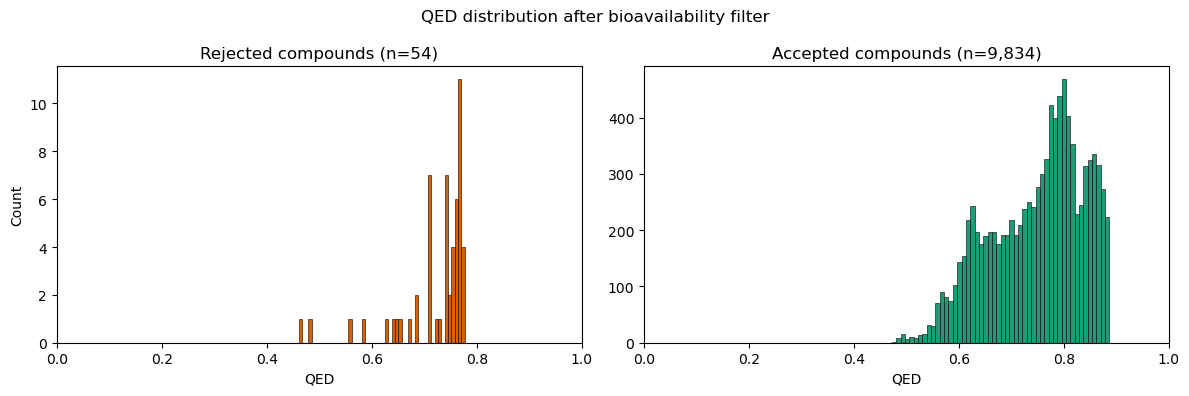

In [5]:
# 0.3s

_fig, _axes = uf.plot_qed_histograms(
    df_imidazolones_druglike=df_imidazolones_druglike,
    df_thiazolones_druglike=df_thiazolones_druglike,
    df_imidazolones_nondruglike=df_imidazolones_nondruglike,
    df_thiazolones_nondruglike=df_thiazolones_nondruglike,
)

## 🔸 5. Price Re-Filtering

Apply independent per-series price controls in this exact order:
1. `max_price`
2. `acceptance_rate` (fraction 0-1, keeps floor(rate*N), min 1 when rate > 0)
3. `max_sample_size` (top-N cheapest after previous controls)

Save accepted clustering inputs and price-control rejections in
`mol_files/7. Clustering/` with row-count suffix naming conventions.

In [6]:
# 0.0s

clustering_paths = uf.run_clustering_input_export(
    df_imidazolones_druglike=df_imidazolones_druglike,
    df_thiazolones_druglike=df_thiazolones_druglike,
    max_price_imi=MAX_PRICE_IMIDAZOLONES,
    max_price_thi=MAX_PRICE_THIAZOLONES,
    accept_rate_imi=ACCEPTANCE_RATE_IMIDAZOLONES,
    accept_rate_thi=ACCEPTANCE_RATE_THIAZOLONES,
    max_sample_imi=MAX_SAMPLE_SIZE_IMIDAZOLONES,
    max_sample_thi=MAX_SAMPLE_SIZE_THIAZOLONES,
)

print("\n=== Hit Prioritization Complete ===")
print(f"Imidazolones clustering input: {len(pd.read_csv(clustering_paths['imidazolones_input'])):,} compounds")
print(f"Thiazolones clustering input:  {len(pd.read_csv(clustering_paths['thiazolones_input'])):,} compounds")

[apply_price_controls] 5,983/8,930 accepted (67.0%), 2,947 rejected
[apply_price_controls] 605/904 accepted (66.9%), 299 rejected
[Save] mol_files/7. Clustering/.inputs/Imidazolones_input_5983cmpds.csv
[Save] mol_files/7. Clustering/.inputs/Thiazolones_input_605cmpds.csv
[Save] mol_files/7. Clustering/.rejected/Imidazolones_rejected_pricectrl_2947cmpds.csv
[Save] mol_files/7. Clustering/.rejected/Thiazolones_rejected_pricectrl_299cmpds.csv

=== Hit Prioritization Complete ===
Imidazolones clustering input: 5,983 compounds
Thiazolones clustering input:  605 compounds


## 🔸 6. ALMOS Clustering

Run ALMOS directly from this notebook using the clustering-input CSV files
generated in Step 5.

- Keep imidazolones and thiazolones fully separate
- Use descriptor mode (no `--aqme`)
- If `ID` contains duplicates, `py_utils.clustering` auto-generates a
  unique temporary ALMOS name column and maps clusters back to the original rows


In [7]:
# 40.3s

import py_utils.clustering as clt

almos_outputs = clt.cluster_inputs(
    imidazolones_input_csv=clustering_paths['imidazolones_input'],
    thiazolones_input_csv=clustering_paths['thiazolones_input'],
    n_clusters_imidazolones=N_CLUSTERS_IMIDAZOLONES,
    n_clusters_thiazolones=N_CLUSTERS_THIAZOLONES,
    top_n_per_cluster=TOP_N_PER_CLUSTER,
    conda_env=ALMOS_CONDA_ENV,
)

print('\n=== ALMOS Clustering Complete ===')
for series, paths in almos_outputs.items():
    print(f"{series.title()}: {len(paths)} outputs")

[validate_distinct_series_inputs] Imidazolones: rows=5,983, sha256=578b0879b270...
[validate_distinct_series_inputs] Thiazolones:  rows=605, sha256=8cbe486a312d...
[validate_clustering_input] rows=5,983, descriptor_cols=14, numeric_like_cols=14
[run_almos_cluster] conda run -n almos python -m almos --cluster --input '/Users/dariomlorente/code/coxib-drug-design/mol_files/7. Clustering/ALMOS/.runs/Imidazolones_20260430T135104Z/Imidazolones_input_5983cmpds_almos_input.csv' --name ID --ignore '['"'"'SMILES'"'"','"'"'Violation'"'"']' --seed_clustered 0
[run_almos_cluster] cwd=/Users/dariomlorente/code/coxib-drug-design/mol_files/7. Clustering/ALMOS/.runs/Imidazolones_20260430T135104Z
[run_almos_cluster] Generated CSV files: 4
[save_clustering_outputs] /Users/dariomlorente/code/coxib-drug-design/mol_files/7. Clustering/ALMOS/Imidazolones_clusters_k40_5983cmpds.csv
[save_clustering_outputs] /Users/dariomlorente/code/coxib-drug-design/mol_files/7. Clustering/ALMOS/Imidazolones_representatives_